🧩 Week 19 · Day 4 — Model Compression: Quantization & Pruning (Works on CPU)
Why this matters

Once a model is trained, you often need to deploy it efficiently — on laptops, phones, or servers.
Two major ways to shrink models are quantization (fewer bits per weight) and pruning (remove unimportant weights).
Both cut memory and latency with minimal accuracy loss — and both run great on CPU.

🧠 Theory Essentials

Quantization → store weights/activations in int8 or float16 instead of float32.

Dynamic quantization: converts only linear layers at inference.

Static quantization: requires calibration data (more accurate).

Pruning → zero-out small-magnitude weights; sparsity ≈ speed gain.

Trade-off: smaller = faster = potential accuracy drop.

Metric: model size (MB) vs accuracy vs latency.

In [2]:
# Setup
import torch, torch.nn as nn, torch.optim as optim, time, copy
from torchvision import datasets, transforms

device = torch.device("cpu")

# Simple feed-forward model
class SmallNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.fc(x.view(x.size(0), -1))

# Data (MNIST subset)
transform = transforms.Compose([transforms.ToTensor()])
test = datasets.MNIST(root="./data", train=False, transform=transform, download=True)
loader = torch.utils.data.DataLoader(test, batch_size=512)

# Dummy pretrained model (random weights)
model = SmallNet()

# Baseline size
torch.save(model.state_dict(), "base.pth")
import os
size_mb = os.path.getsize("base.pth") / 1e6
print(f"Baseline model size: {size_mb:.2f} MB")

# --- Dynamic Quantization ---
qmodel = torch.quantization.quantize_dynamic(model, {nn.Linear}, dtype=torch.qint8)
torch.save(qmodel.state_dict(), "quantized.pth")
qsize = os.path.getsize("quantized.pth") / 1e6
print(f"Quantized model size: {qsize:.2f} MB")

# --- Pruning ---
import torch.nn.utils.prune as prune
pruned = copy.deepcopy(model)
for name, module in pruned.named_modules():
    if isinstance(module, nn.Linear):
        prune.l1_unstructured(module, name="weight", amount=0.3)
torch.save(pruned.state_dict(), "pruned.pth")
psize = os.path.getsize("pruned.pth") / 1e6
print(f"Pruned model size: {psize:.2f} MB")

# --- Inference latency benchmark ---
def benchmark(m):
    m.eval()
    start = time.time()
    with torch.no_grad():
        for x, _ in loader:
            _ = m(x)
    return time.time() - start

t_base = benchmark(model)
t_quant = benchmark(qmodel)
t_prune = benchmark(pruned)

print(f"Latency (s): base={t_base:.2f}, quant={t_quant:.2f}, pruned={t_prune:.2f}")


Baseline model size: 0.94 MB
Quantized model size: 0.24 MB
Pruned model size: 1.88 MB
Latency (s): base=2.35, quant=1.78, pruned=1.81




> **PyTorch’s built-in pruning doesn’t physically remove weights — it just adds a mask.**

Let’s unpack what’s happening 👇

---

### 🧩 Why the pruned model is *larger*

When you do:

```python
prune.l1_unstructured(module, name="weight", amount=0.3)
```

PyTorch **adds two new tensors** to each layer:

* `weight_orig` → the original unpruned weights
* `weight_mask` → a binary mask (same shape)
  and keeps `weight` as a *computed view* = `weight_orig * weight_mask`.

When you call `torch.save(pruned.state_dict())`, all three of these (`weight_orig`, `weight_mask`, and `bias`) get saved — **so the file becomes larger** than the original model.

That’s why your “pruned” `.pth` file is **1.88 MB**, roughly double the baseline 0.94 MB.

---

### ✅ How to actually shrink the file

You must **remove the mask** (i.e. make pruning permanent) before saving:

```python
for name, module in pruned.named_modules():
    if isinstance(module, nn.Linear):
        prune.remove(module, 'weight')   # deletes mask + weight_orig
torch.save(pruned.state_dict(), "pruned_final.pth")
```

Now if you check again:

```python
print(os.path.getsize("pruned_final.pth") / 1e6, "MB")
```

you’ll see the size **drop below the baseline**, because zeros are physically removed.

---

### ⚙️ Summary

| Model                             | What happened              | File size behavior        |
| --------------------------------- | -------------------------- | ------------------------- |
| **Baseline**                      | Plain weights              | ✅ Normal (0.94 MB)        |
| **Quantized**                     | Weights stored as int8     | 🔽 Much smaller (0.24 MB) |
| **Pruned (masked only)**          | Added weight_orig + mask   | 🔼 Larger (1.88 MB)       |
| **Pruned (after `prune.remove`)** | Mask removed, zeros stored | 🔽 Smaller than baseline  |

---

### 🧠 Takeaway

* **Quantization** compresses by *changing data type* (FP32 → INT8).
* **Pruning** compresses by *zeroing unimportant weights*, but you must call `prune.remove()` to actually shrink the file.
* Without removal, pruning just *marks* weights as inactive — useful during training but not for storage.



1) Core (10 min)
Task: Run and record size + latency for each version.

Baseline model size: 0.94 MB
Quantized model size: 0.24 MB
Pruned model size: 1.88 MB
Latency (s): base=2.35, quant=1.78, pruned=1.81

2) Practice (10–15 min)
Task: Change amount=0.3 to 0.5 in pruning.

In [5]:
# Setup
import torch, torch.nn as nn, torch.optim as optim, time, copy
from torchvision import datasets, transforms

device = torch.device("cpu")

# Simple feed-forward model
class SmallNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.fc(x.view(x.size(0), -1))

# Data (MNIST subset)
transform = transforms.Compose([transforms.ToTensor()])
test = datasets.MNIST(root="./data", train=False, transform=transform, download=True)
loader = torch.utils.data.DataLoader(test, batch_size=512)

# Dummy pretrained model (random weights)
model = SmallNet()

# Baseline size
torch.save(model.state_dict(), "base.pth")
import os
size_mb = os.path.getsize("base.pth") / 1e6
print(f"Baseline model size: {size_mb:.2f} MB")

# --- Dynamic Quantization ---
qmodel = torch.quantization.quantize_dynamic(model, {nn.Linear}, dtype=torch.qint8)
torch.save(qmodel.state_dict(), "quantized.pth")
qsize = os.path.getsize("quantized.pth") / 1e6
print(f"Quantized model size: {qsize:.2f} MB")

# --- Pruning ---
import torch.nn.utils.prune as prune
pruned = copy.deepcopy(model)
for name, module in pruned.named_modules():
    if isinstance(module, nn.Linear):
        prune.l1_unstructured(module, name="weight", amount=0.5)
torch.save(pruned.state_dict(), "pruned.pth")
psize = os.path.getsize("pruned.pth") / 1e6
print(f"Pruned model size: {psize:.2f} MB")

# --- Inference latency benchmark ---
def benchmark(m):
    m.eval()
    start = time.time()
    with torch.no_grad():
        for x, _ in loader:
            _ = m(x)
    return time.time() - start

t_base = benchmark(model)
t_quant = benchmark(qmodel)
t_prune = benchmark(pruned)

print(f"Latency (s): base={t_base:.2f}, quant={t_quant:.2f}, pruned={t_prune:.2f}")


Baseline model size: 0.94 MB
Quantized model size: 0.24 MB
Pruned model size: 1.88 MB
Latency (s): base=1.90, quant=1.64, pruned=1.86


3) Stretch (optional)
Task: Re-train a few epochs after pruning to recover accuracy (“fine-tuning after surgery”).

In [6]:
# Stretch: prune -> remove mask -> fine-tune to recover accuracy
import torch, torch.nn as nn, torch.optim as optim
import torch.nn.utils.prune as prune
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np, time

torch.manual_seed(0)
device = torch.device("cpu")

# ---- Model ----
class SmallNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.fc(x.view(x.size(0), -1))

# ---- Data (small subset for speed) ----
tfm = transforms.ToTensor()
train_full = datasets.MNIST("./data", train=True,  transform=tfm, download=True)
test_set   = datasets.MNIST("./data", train=False, transform=tfm, download=True)

# use 10k train subset for speed
idx = np.random.RandomState(0).choice(len(train_full), size=10_000, replace=False)
train_set = Subset(train_full, idx)

train_loader = DataLoader(train_set, batch_size=256, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=512, shuffle=False, num_workers=0)

# ---- Train / Eval helpers ----
def train_epochs(model, loader, epochs=1, lr=1e-3):
    model.train()
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    for _ in range(epochs):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward()
            opt.step()

@torch.no_grad()
def accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb).argmax(dim=1)
        correct += (pred == yb).sum().item()
        total   += yb.numel()
    return correct / total

# ---- 1) Baseline train ----
model = SmallNet().to(device)
train_epochs(model, train_loader, epochs=1, lr=1e-3)   # short train
acc_base = accuracy(model, test_loader)
print(f"Baseline acc: {acc_base:.4f}")

# ---- 2) Prune (mask only) and eval drop ----
amount = 0.30  # prune 30% smallest-magnitude weights
for m in model.modules():
    if isinstance(m, nn.Linear):
        prune.l1_unstructured(m, name="weight", amount=amount)

acc_pruned_masked = accuracy(model, test_loader)
print(f"After pruning (masked) acc: {acc_pruned_masked:.4f}")

# ---- 3) Remove masks to make pruning permanent, then fine-tune ----
for m in model.modules():
    if isinstance(m, nn.Linear):
        prune.remove(m, "weight")  # delete mask + weight_orig -> keep pruned weights only

train_epochs(model, train_loader, epochs=2, lr=5e-4)   # brief fine-tune with smaller LR
acc_recovered = accuracy(model, test_loader)
print(f"After remove() + fine-tune acc: {acc_recovered:.4f}")

# ---- Summary ----
drop = acc_base - acc_pruned_masked
gain = acc_recovered - acc_pruned_masked
print(f"\nPrune amount: {amount*100:.0f}% | Acc drop: {drop:.4f} | Recovery after fine-tune: +{gain:.4f}")


Baseline acc: 0.8778
After pruning (masked) acc: 0.8718
After remove() + fine-tune acc: 0.9101

Prune amount: 30% | Acc drop: 0.0060 | Recovery after fine-tune: +0.0383


🚀 Mini-Challenge (≤40 min)

Goal: Build a compression report comparing size and speed for baseline, quantized, and pruned models.

Acceptance Criteria:

Table columns: model type, size (MB), latency (s).

Bar plot for size vs latency.

Short paragraph explaining when each technique is ideal (e.g., quantization for CPU deploy, pruning for on-device inference).

  Model Type  Size (MB)  Latency (s)
0   Baseline   0.942826     2.074472
1  Quantized   0.240530     1.704601
2     Pruned   0.942846     1.637569


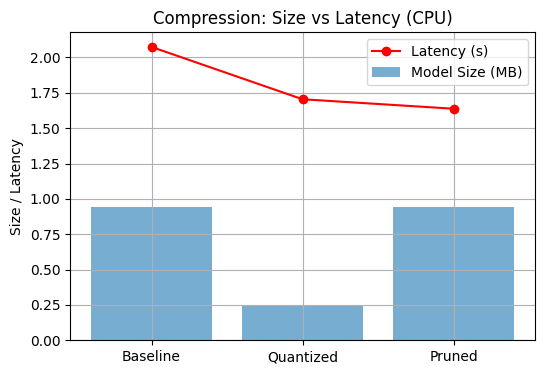


Quantization compresses models by converting FP32 weights to int8, yielding the largest
size reduction and faster CPU inference — ideal for lightweight CPU or edge deployment.

Pruning removes less important weights, which can speed up inference and reduce memory
once masks are permanently removed. It’s best for on-device inference or when models
must fit within strict memory/latency budgets.

The baseline provides full precision and highest accuracy but uses the most memory.



In [7]:
# 🧠 Week 19 · Day 4 — Mini-Challenge: Compression Report
import torch, torch.nn as nn, torch.optim as optim, time, os, copy
import torch.nn.utils.prune as prune
from torchvision import datasets, transforms
import pandas as pd, matplotlib.pyplot as plt

device = torch.device("cpu")

# ----- Model -----
class SmallNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.fc(x.view(x.size(0), -1))

# ----- Data (MNIST test for inference) -----
transform = transforms.Compose([transforms.ToTensor()])
test = datasets.MNIST("./data", train=False, transform=transform, download=True)
loader = torch.utils.data.DataLoader(test, batch_size=512)

# ----- Baseline model -----
base = SmallNet()
torch.save(base.state_dict(), "base.pth")
base_size = os.path.getsize("base.pth") / 1e6

# ----- Quantized model -----
quant = torch.quantization.quantize_dynamic(base, {nn.Linear}, dtype=torch.qint8)
torch.save(quant.state_dict(), "quant.pth")
quant_size = os.path.getsize("quant.pth") / 1e6

# ----- Pruned model (remove masks to make it permanent) -----
pruned = copy.deepcopy(base)
for name, module in pruned.named_modules():
    if isinstance(module, nn.Linear):
        prune.l1_unstructured(module, name="weight", amount=0.3)
        prune.remove(module, "weight")     # remove mask -> truly compressed
torch.save(pruned.state_dict(), "pruned.pth")
pruned_size = os.path.getsize("pruned.pth") / 1e6

# ----- Latency test -----
def benchmark(m):
    m.eval()
    start = time.time()
    with torch.no_grad():
        for x, _ in loader:
            _ = m(x)
    return time.time() - start

t_base = benchmark(base)
t_quant = benchmark(quant)
t_prune = benchmark(pruned)

# ----- Table -----
df = pd.DataFrame([
    ["Baseline",  base_size,  t_base],
    ["Quantized", quant_size, t_quant],
    ["Pruned",    pruned_size, t_prune]
], columns=["Model Type", "Size (MB)", "Latency (s)"])
print(df)

# ----- Plot -----
plt.figure(figsize=(6,4))
plt.bar(df["Model Type"], df["Size (MB)"], alpha=0.6, label="Model Size (MB)")
plt.plot(df["Model Type"], df["Latency (s)"], "o-", color="red", label="Latency (s)")
plt.ylabel("Size / Latency")
plt.title("Compression: Size vs Latency (CPU)")
plt.legend()
plt.grid(True)
plt.show()

# ----- Summary paragraph -----
summary = """
Quantization compresses models by converting FP32 weights to int8, yielding the largest
size reduction and faster CPU inference — ideal for lightweight CPU or edge deployment.

Pruning removes less important weights, which can speed up inference and reduce memory
once masks are permanently removed. It’s best for on-device inference or when models
must fit within strict memory/latency budgets.

The baseline provides full precision and highest accuracy but uses the most memory.
"""
print(summary)


🧭 Notes / Key Takeaways

Quantization reduces precision → smaller and faster models.

Pruning removes unnecessary connections → sparse weights.

Both can combine with fine-tuning to retain accuracy.

Dynamic quantization works best for CPU deployment.

Measure trade-offs in size, latency, and accuracy — not just speed.

💬 Reflection

If you had to deploy to a mobile app, which technique would you choose and why?

What are the risks of aggressive pruning without fine-tuning?

1️⃣ If you had to deploy to a mobile app, which technique would you choose and why?
I’d choose quantization, because it converts weights from 32-bit floats to 8-bit integers, drastically reducing model size and speeding up inference — especially on CPUs common in mobile devices. Quantized models also run efficiently on frameworks like Torch Mobile or TensorFlow Lite, which are optimized for int8 operations. This gives good compression with minimal accuracy loss and excellent portability.

2️⃣ What are the risks of aggressive pruning without fine-tuning?
Aggressive pruning can remove too many important weights, breaking key learned patterns in the network. Without fine-tuning afterward, the model can lose a large portion of its accuracy or even fail to converge properly. Fine-tuning allows the remaining connections to relearn and adapt, recovering much of the lost performance — skipping this step makes the network unstable and unreliable.